In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
training = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [ ]:
training.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Lets see generate a heatmap to see how many which columns have null values

<Axes: >

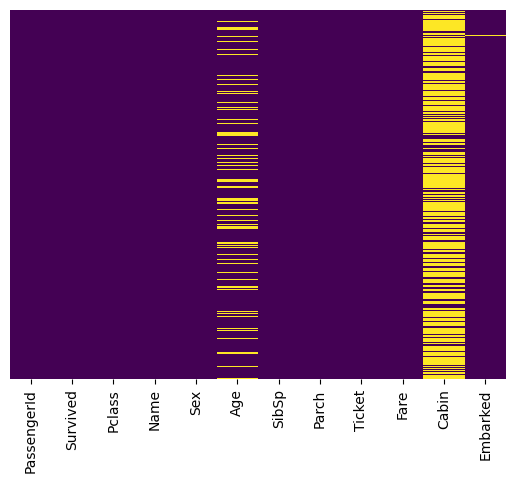

In [ ]:
sns.heatmap(training.isnull(),yticklabels=False,cbar =False,cmap='viridis')

Now that we know that two column age and cabin have null values in it we will try to fill it . Before that lets check what is the survival rate

In [ ]:
training['Survived'].mean()

np.float64(0.3838383838383838)

So the survival rate was 38% , now lets check how many male or female passenger were there in the boat which will help us find the number of survivors according to sex

In [ ]:
print(training['Sex'].value_counts(normalize=True))

Sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64


So we can see that there were 64% male and 35% female passengers on board.Now lets see what was there survival chances

In [ ]:
print(training['Survived'].groupby(training['Sex']).mean())

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


So 74% of females survived the crash , which is true according to the historical facts childerens and females were given priority. Now lets see the age of the survivors

/tmp/ipykernel_1629/4053421260.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  training['Survived'].groupby(pd.cut(training['Age'],20)).mean().plot(kind = 'bar')


<Axes: xlabel='Age'>

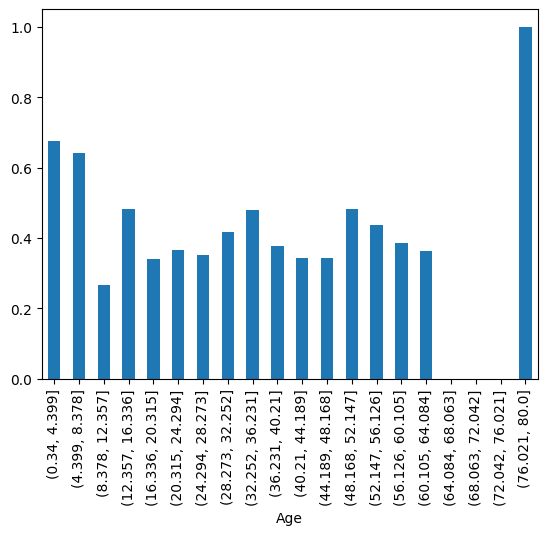

In [ ]:
training['Survived'].groupby(pd.cut(training['Age'],20)).mean().plot(kind = 'bar')

So many childrens and some old people survived. So social status was a big thing during 1910s so lets see if it was a factor to affect the chances of survival?

/tmp/ipykernel_1629/3783585302.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  training['Survived'].groupby(pd.cut(training['Fare'],[5,10,20,30,50,70,100])).mean().plot(kind= 'bar')


<Axes: xlabel='Fare'>

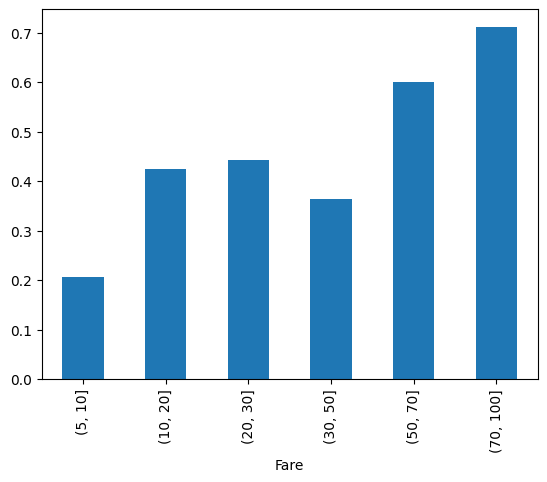

In [ ]:
training['Survived'].groupby(pd.cut(training['Fare'],[5,10,20,30,50,70,100])).mean().plot(kind= 'bar')

So we can see that the passengers who paid 70 dollars had more chances of survival than that of 5 dollars. This gave us a little bit of hint for what our featur enginnering might be so lets see that if the title of the person affects the chances of survival?

In [ ]:
import re

all_names = training['Name'].str.split(',|/.' ,expand = True)

# Extract last name from the split parts
training['last_name'] = all_names[0].str.strip()

# Extract title: Look for a word followed by a dot, after a comma and optional space
# This is more robust as titles are consistently followed by a dot in this dataset format.
training['title'] = training['Name'].str.extract(r',\s*([A-Za-z]+)\.', expand=False)
training['title'] = training['title'].fillna('Unknown').str.strip() # Fill NaNs and strip whitespace

# Extract given name: This function extracts the part after 'LastName, Title.' and before any parentheses.
def extract_given_name(name_str):
    if not isinstance(name_str, str):
        return ''
    # Match the pattern 'LastName, Title. GivenName' and optionally capture text before '('
    match = re.search(r',\s*[A-Za-z]+\.\s*(.*?)(?:\s*\(| tactics|$)', name_str)
    if match:
        return match.group(1).strip()
    return ''

training['given_name'] = training['Name'].apply(extract_given_name)
training['given_name'] = training['given_name'].fillna('')

# Display the value counts for the (now corrected) titles
display(training['title'].value_counts())

,count
title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [ ]:
print(f"Number of null values in 'title' column: {training['title'].isnull().sum()}")

Number of null values in 'title' column: 0


As you can see, there are null values in the `title` column. To ensure titles are extracted correctly and avoid these nulls, we should use a more precise method. `str.extract` with a regular expression is ideal for this. It directly extracts the pattern we're looking for (a word followed by a period before the rest of the name).

In [ ]:
# A more robust way to extract titles
training['title'] = training['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Re-run the value counts to see the improved titles
display(training['title'].value_counts())

# Check for nulls in title again
print(f"Number of null values in 'title' column after extraction: {training['title'].isnull().sum()}")

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1629/833102660.py:2: SyntaxWarning: invalid escape sequence '\.'
  training['title'] = training['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,count
title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


Number of null values in 'title' column after extraction: 0


In [ ]:
cat = { 'Capt':'Military',
            'Col':'Military',
            'Don':'Noble',
            'Dona':'Noble',
            'Dr':'Dr',
            'Jonkheer':'Noble',
            'Lady':'Noble',
            'Major':'Military',
            'Master':'Common',
            'Miss':'Common',
            'Mlle':'Common',
            'Mme':'Common',
            'Mr':'Common',
            'Mrs':'Common',
            'Ms':'Common',
            'Rev':'Clergy',
            'Sir':'Noble',
            'the Countess':'Noble',
            'Countess':'Noble' # Added mapping for 'Countess'
}
training['Social_status']= training['title'].map(cat)

Now that we made a column called social status which stores the title of the people lets see does this affects the chances of survival?


<Axes: xlabel='Social_status'>

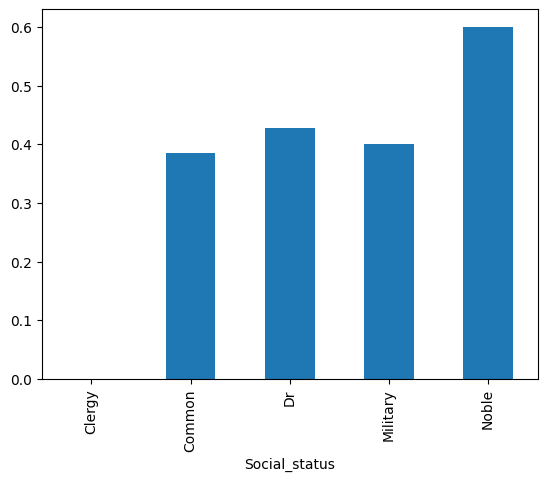

In [ ]:
training['Survived'].groupby(training['Social_status']).mean().plot(kind = 'bar')

Now we can see that common people had less chance of survival than that of the Noble.Now that we know that social status can be a factor for the chances of survival now lets see if the size of the family affect the chances of survival or not .

In [ ]:
training['Family'] = training['SibSp']+training['Parch']
training['Family'].head()

,Family
0,1
1,1
2,0
3,1
4,0


<Axes: xlabel='Family'>

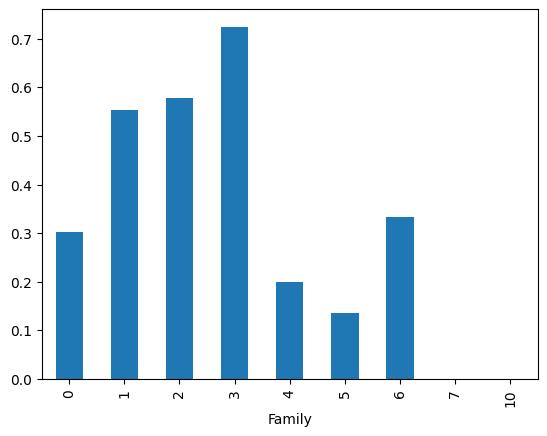

In [ ]:
training['Survived'].groupby(training['Family']).mean().plot(kind = 'bar')

So the Family with family with 3 family members have more chances of survival that that of the family that are bigger than 3. W can also see that passenger with no famlily member had less chances of survival we can assume that they helped other family to escape from the both as they didnt had there own family to protect first

In [ ]:
training.isnull().any()

,0
PassengerId,False
Survived,False
Pclass,False
Name,False
Sex,False
Age,True
SibSp,False
Parch,False
Ticket,False
Fare,False


Now lets fill the null values


In [ ]:
training['Age'] = training['Age'].fillna(training['Age'].median())

In [ ]:
training.isnull().any()

,0
PassengerId,False
Survived,False
Pclass,False
Name,False
Sex,False
Age,False
SibSp,False
Parch,False
Ticket,False
Fare,False


In [ ]:
training['Fare'] = training['Fare'].fillna(training['Fare'].median())

In [ ]:
training.isnull().any()

,0
PassengerId,False
Survived,False
Pclass,False
Name,False
Sex,False
Age,False
SibSp,False
Parch,False
Ticket,False
Fare,False


In [ ]:
training['Embarked'] = training['Embarked'].fillna(training['Embarked'].mode()[0])
display(training['Embarked'])

,Embarked
0,S
1,C
2,S
3,S
4,S
...,...
886,S
887,S
888,S
889,C


In [ ]:
training.isnull().any()

,0
PassengerId,False
Survived,False
Pclass,False
Name,False
Sex,False
Age,False
SibSp,False
Parch,False
Ticket,False
Fare,False


In [ ]:
drop_data = ['Name','Ticket','Cabin','SibSp','Parch','PassengerId','last_name','title','given_name']
cols_data = [cols for cols in drop_data if cols in training.columns]

if cols_data:
    dropped_data = training.drop(cols_data,axis=1,inplace=True)


In [ ]:
training.isnull().any()

,0
Survived,False
Pclass,False
Sex,False
Age,False
Fare,False
Embarked,False
Social_status,False


Now lets encode categorical data that are of Nominal Type(Data with no natural order) in this case it is sex and embarked

In [ ]:
embark= pd.get_dummies(training['Embarked'],prefix = 'Embarked',drop_first=True,dtype = int)

drop_embark = training.drop('Embarked',axis =1,errors='Ignore')
training = pd.concat([embark,drop_embark],axis=1)

In [ ]:
training.isnull().any()

,0
Embarked_Q,False
Embarked_S,False
Survived,False
Pclass,False
Sex,False
Age,False
Fare,False
Social_status,False


In [ ]:
Sex_enco = pd.get_dummies(training['Sex'],drop_first=True,prefix= 'Sex',dtype=int)

if 'Sex' in training.columns:
  drop_sex = training.drop('Sex',axis =1)
training = pd.concat([Sex_enco,drop_sex],axis = 1)

In [ ]:
social_status_enco = pd.get_dummies(training['Social_status'],drop_first=True,dtype =int)
training = pd.concat([training,social_status_enco],axis=1)

Now That we cleaned the data and feature enginnered now lets check our model's prediction

In [ ]:
training = training.drop('Social_status',axis =1)

In [ ]:
from sklearn.model_selection import train_test_split

In [97]:
X= training.drop(['Survived'],axis =1)
y = training['Survived']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.40)



In [98]:
from sklearn.ensemble import RandomForestClassifier

In [99]:
model = RandomForestClassifier(random_state = 1)
model.fit(X_train,y_train)

RandomForestClassifier(random_state=1)

In [100]:
pred = model.predict(X_test)

In [101]:
from sklearn.metrics import confusion_matrix

In [102]:
accuracy = confusion_matrix(y_test,pred)
accuracy

array([[185,  28],
       [ 41, 103]])

In [103]:
from sklearn.metrics import accuracy_score

In [104]:
accuracy = accuracy_score(y_test,pred)
accuracy

0.8067226890756303